In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

In [2]:
df_train_init = pd.read_csv("train.csv", sep=';', parse_dates=['date'], index_col='date')
df_test_init = pd.read_csv("test.csv", sep=';', parse_dates=['date'], index_col='date')
df_train_monthly = df_train_init.interpolate(method='time').resample('ME').mean()
df_test_monthly = df_test_init.interpolate(method='time').resample('ME').mean()

In [3]:
nb_valid = 48 
df_train = df_train_monthly[:-nb_valid].copy()
df_valid = df_train_monthly[-nb_valid:].copy()
print("Train shape :", df_train.shape)
print("Valid shape :", df_valid.shape)

Train shape : (240, 1)
Valid shape : (48, 1)


In [4]:
model = ExponentialSmoothing(
    df_train['target'], 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12,
    use_boxcox=False
)
fitted_model = model.fit()
print(fitted_model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                   target   No. Observations:                  240
Model:             ExponentialSmoothing   SSE                            154.505
Optimized:                         True   AIC                            -73.699
Trend:                         Additive   BIC                            -18.009
Seasonal:                      Additive   AICC                           -70.604
Seasonal Periods:                    12   Date:                 Mon, 23 Mar 2026
Box-Cox:                          False   Time:                         15:24:24
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               1.0000000                alpha                 True
smoothing_trend          

In [5]:
predictions = fitted_model.forecast(len(df_valid))
mse = mean_squared_error(df_valid['target'], predictions)
print(f"\nMSE sur la validation : {mse:.4f}")


MSE sur la validation : 4.0385


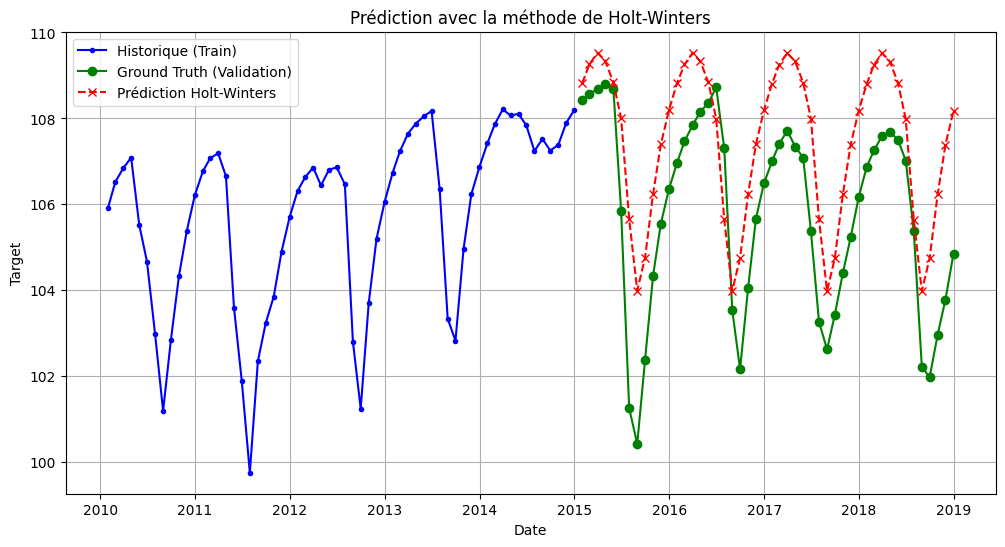

In [6]:
plt.figure(figsize=(12, 6))
hist_len = 60
hist_idx = df_train.index[-hist_len:]
hist_target = df_train['target'].iloc[-hist_len:]
plt.plot(hist_idx, hist_target, label='Historique (Train)', color='blue', marker='.')
plt.plot(df_valid.index, df_valid['target'], label='Ground Truth (Validation)', color='green', marker='o')
plt.plot(df_valid.index, predictions, label='Prédiction Holt-Winters', color='red', linestyle='--', marker='x')
plt.title('Prédiction avec la méthode de Holt-Winters')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()